In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore,pearsonr,wilcoxon,mannwhitneyu,kruskal
from scipy.ndimage import median_filter

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }  
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)

def format_ax(ax,xlim,ylim,xspace,yspace):
    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))
    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [2]:
### Function to align trials to event onsets, 
### Adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [3]:
###low pass filter pupil
def filter_pupil(pupil,order = 1,cutoff = 1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y

    return butter_lowpass_filter(pupil, cutoff, fs, order)

In [ ]:
### Pupil event detection function

def get_pupil_events(id,date):
    id = id
    date = date
    face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    df = pd.read_csv(path)
    pupil = np.array(df["Pupil Size"])
    time = np.array(df["Time"])
    speed = np.array(df["Running Speed"])
    speed[0] = 0
    dff = np.array(df["dFF"])
    face = np.array(pd.read_csv(face_path)["Facial Movement"])

    ###Onset detection alogrithm

    filter = filter_pupil(pupil) ###first apply low pass filter to pupil trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]

    ##join regions that are near eachother again
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = 36000
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(filter[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)

    ###get dff data
    aucs = []
    peak_dffs = []
    mean_dffs = []
    for onset,offset in zip(onsets_ix,offset_ix):
        peak_dffs.append(max(dff[onset:offset]) - np.mean(dff[onset-30:onset]))
        aucs.append(np.trapz(dff[onset:offset]))
        mean_dffs.append(np.mean(dff[onset:offset])- np.mean(dff[onset-20:onset]))

    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    "peak_dff" : peak_dffs,
    "aucs" : aucs,
    "mean_dff" : mean_dffs,


    }
    

    return pd.DataFrame.from_dict(events_dict)


In [5]:
###helper functions to get locomotion and non-locomotion events based on running speed data
def get_movement_events(events,speed):
    onsets = [on for on in events["onsets"]] ###get pupil onsets ix
    offsets = [off for off in events["offsets"]] ###get pupil offsets ix
    events_ix = []
    for i,(on,off) in enumerate(zip(onsets,offsets)):
        if np.mean(speed[on:off]) >np.percentile(speed,65):
            events_ix.append(i)

    return events_ix
    
def get_quiet_events(events,speed):
    speed = abs(speed)
    onsets = [on for on in events["onsets"]] ###get pupil onsets ix
    offsets = [off for off in events["offsets"]] ###get pupil offsets ix
    events_ix = []
    for i,(on,off) in enumerate(zip(onsets,offsets)):
        if np.mean(speed[on:off]) <np.percentile(speed,45):
            events_ix.append(i)
     
    return events_ix

In [33]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [ ]:
### get sample trace data for Fig1B
id = "004116"
date = "20230815"
face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
df = pd.read_csv(path)
pupil = np.array(df["Pupil Size"])
time = np.array(df["Time"])
dff = np.array(df["dFF"])
face = np.array(pd.read_csv(face_path)["Facial Movement"])
df["Facial Movement"] = face
df["Running Speed"] = zscore(np.array(df["Running Speed"]))
events = get_pupil_events(id,date)


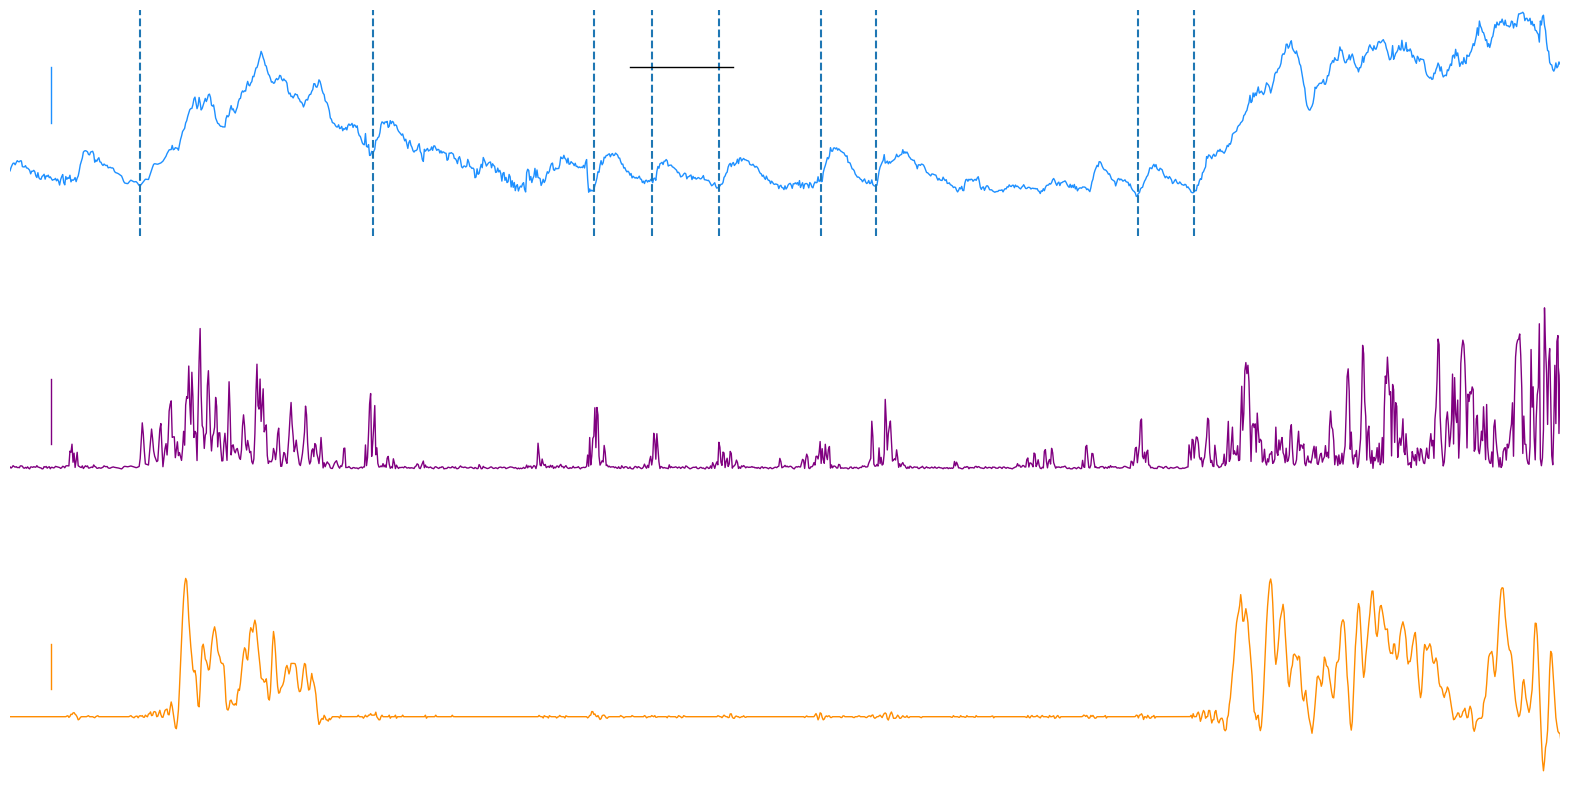

In [7]:
### Plot Fig1B

ax2,(ax1,ax2,ax3) = plt.subplots(3,figsize = (20,10))
onsets = [on/20 for on in events["onsets"]]

sns.lineplot(data = df, x = "Time", y = "Pupil Size", ax = ax1,color = "dodgerblue",linewidth = 1)
sns.lineplot(data = df, x = "Time", y = "Facial Movement", ax = ax2,linewidth = 1,color = "purple")
sns.lineplot(data = df, x = "Time", y = "Running Speed",ax = ax3,linewidth = 1,color = "darkorange")

for on in onsets:
    ax1.axvline(on,linestyle = "dashed")

x_start = 1510
x_end = 1585
x_space = 5
ylim = [-4,4]

for ax in [ax1,ax2,ax3]:
    ax.set_xlim(x_start,x_end)
    ax.set_xticks(np.arange(x_start,x_end + x_space,x_space))
    ax.set_ylim(ylim)

ax3.set_ylim(-2,3)
ax1.set_ylim(-2,2)
ax2.set_ylim(-2,5)

ax1.spines[['bottom']].set_visible(False)
ax1.spines[['left']].set_visible(False)

ax1.get_xaxis().set_visible(False)
ax1.get_yaxis().set_visible(False)



ax2.spines[['bottom']].set_visible(False)
ax2.spines[['left']].set_visible(False)

ax2.get_xaxis().set_visible(False)
ax2.get_yaxis().set_visible(False)



ax3.spines[['bottom']].set_visible(False)
ax3.spines[['left']].set_visible(False)

ax3.get_xaxis().set_visible(False)
ax3.get_yaxis().set_visible(False)




ax1.plot([1540,1545], [1, 1],color = "black",linewidth = 1)

ax1.plot([1512,1512], [0, 1],color = "dodgerblue",linewidth = 1)
ax2.plot([1512,1512], [0, 2],color = "purple",linewidth = 1)
ax3.plot([1512,1512], [0, 1],color = "darkorange",linewidth = 1)



/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2229396088.py:41: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = r_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "R",errorbar="se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2229396088.py:42: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = r_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "R",color = "black",alpha = 0.3,s = 4,jitter = 0.1)


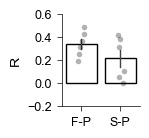

In [ ]:
### Get data for Fig 1C

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}
df_list = []


for id,dates in id_date.items():
    for date in dates:
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = (np.array(df["Running Speed"]))
        speed[0] = 0
        speed = zscore(speed)

        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        df["Facial Movement"] = face

        new_dict = {"R":pearsonr(face,pupil)[0], "type": "F-P", "ID" : id, "Date": date}
        df_list.append(new_dict)
        # new_dict = {"R":pearsonr(face,speed)[0], "type": "F-S", "ID" : id, "Date": date}
        # df_list.append(new_dict)
        new_dict = {"R":pearsonr(speed,pupil)[0], "type": "S-P", "ID" : id, "Date": date}
        df_list.append(new_dict)

r_df = pd.DataFrame.from_dict(df_list)

In [ ]:
### Plot Fig1C

plt.figure(figsize = (1,1.2))
g = sns.barplot(data = r_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "R",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = r_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "R",color = "black",alpha = 0.3,s = 4,jitter = 0.1)

g.set_yticks(np.arange(-0.2,0.8,0.2))
g.set(ylim=(-0.2, 0.6))
g.xaxis.label.set_visible(False)



In [ ]:
### Cross-Correlation Analysis for Fig1D and Fig1E
pre = 2
post =2

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
graph_df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        amplitudes = events["amplitudes"]

        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = (np.array(df["Running Speed"]))
        speed = zscore(speed)

        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = pre, post = post)
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = pre, post = post)
        wheel_matrix,wheel_times = trial_align(onsets,time,speed,fps = 20,pre = pre, post = post)

        corr = correlate(np.mean(wheel_matrix,axis=0), np.mean(dil_matrix,axis = 0))
        lags = correlation_lags(len(np.mean(wheel_matrix,axis=0)), len(np.mean(dil_matrix,axis = 0)))
        lags = lags/20
        corr /= np.max(corr)
        i = np.argmax(corr)
        delay = lags[i]
        lag_dict = {"Cross-Correlation Delay (s)" : delay,"ID": id, "date" : date,"type":"S-P"}
        df_list.append(lag_dict)

        for lag,c in zip(lags,corr):
            graph_dict = {"Lags (s)" : lag,"Cross-Correlation": c,"ID": id, "date" : date,"type":"S-P"}
            graph_df_list.append(graph_dict)


        corr = correlate(np.mean(face_matrix,axis=0), np.mean(dil_matrix,axis = 0))
        lags = correlation_lags(len(np.mean(face_matrix,axis=0)), len(np.mean(dil_matrix,axis = 0)))
        lags = lags/20
        corr /= np.max(corr)
        i = np.argmax(corr)
        delay = lags[i]
        lag_dict = {"Cross-Correlation Delay (s)" : delay,"ID": id, "date" : date,"type":"F-P"}
        df_list.append(lag_dict)

        for lag,c in zip(lags,corr):
            graph_dict = {"Lags (s)" : lag,"Cross-Correlation": c,"ID": id, "date" : date,"type":"F-P"}
            graph_df_list.append(graph_dict)

lag_df = pd.DataFrame.from_dict(df_list)
graph_df = pd.DataFrame.from_dict(graph_df_list)





/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/145364022.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = graph_df.groupby(["ID",'type','Lags (s)']).mean().reset_index(), x = "Lags (s)", y = "Cross-Correlation",errorbar="se",hue = "type",palette = ["purple","darkorange"],legend=None,linewidth = 1)


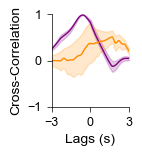

In [10]:
### Plot Fig1D
plt.figure(figsize = (1,1.2))
ax = sns.lineplot(data = graph_df.groupby(["ID",'type','Lags (s)']).mean().reset_index(), x = "Lags (s)", y = "Cross-Correlation",errorbar="se",hue = "type",palette = ["purple","darkorange"],legend=None,linewidth = 1)
format_ax(ax,(-3,3),(-1,1),3,1)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/42060304.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = lag_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "Cross-Correlation Delay (s)",errorbar= "se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/42060304.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = lag_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "Cross-Correlation Delay (s)",color = "black",alpha = 0.3,s = 3,jitter = 0.2)


Text(0, 0.5, 'Cross-Correlation\nDelay (s)')

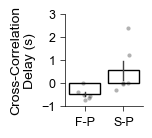

In [11]:
### Plot Fig1E
plt.figure(figsize = (1,1.2))
g = sns.barplot(data = lag_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "Cross-Correlation Delay (s)",errorbar= "se",fill = None,errwidth= 1)
sns.stripplot(data = lag_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "Cross-Correlation Delay (s)",color = "black",alpha = 0.3,s = 3,jitter = 0.2)


g.set_yticks(np.arange(-1,4,1))
g.set(ylim=(-1, 3))
g.xaxis.label.set_visible(False)
g.set_ylabel("Cross-Correlation\nDelay (s)")


[Text(100, 0, '0'), Text(110, 0, '10'), Text(120, 0, '20'), Text(130, 0, '30')]

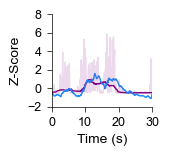

In [ ]:
### Plot Fig1F

id_date = {
  "004115":["20230815"],
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore(abs(np.array(df["Running Speed"])))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        rs = []
        sizes = list(range(1,500,10))
        for size in sizes:
            smoothed = median_filter(face,size)
            r = pearsonr(smoothed,pupil)[0]
            rs.append(r)
            new_dict = {"R":r, "Window Size (s)": size, "ID" : id, "Date": date}
            df_list.append(new_dict)
        
        size = sizes[np.argmax(rs)]
       


plt.figure(figsize = (1.3,1.2))
smoothed = median_filter(face,size)
plt.plot(time,smoothed,linewidth = 1,color  = "purple")
plt.plot(time,pupil,linewidth = 1,color = "dodgerblue")
plt.plot(time,face,alpha = 0.15,linewidth = 1,color = "purple")

plt.xlabel('Time (s)')
plt.ylabel('Z-Score')


format_ax(plt.gca(),(100,130),(-2,8),10,2)
plt.gca().set_xticklabels(range(0,40,10))   


In [ ]:
### Median filter pupil-face correlation analysis for Fig1G
id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        rs = []
        sizes = list(range(1,120,20))
        for size in sizes:
            smoothed = median_filter(face,size)
            r = pearsonr(smoothed,pupil)[0]
            rs.append(r)
            new_dict = {"R":r, "Window": size/20, "ID" : id, "Date": date,"type" : "F-P (Smoothed Face)"}
            df_list.append(new_dict)

            smoothed = median_filter(pupil,size)
            r = pearsonr(smoothed,face)[0]
            new_dict = {"R":r, "Window": size/20, "ID" : id, "Date": date, "type" : "F-P (Smoothed Pupil)"}
            df_list.append(new_dict)

  
median_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2073860769.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = median_df.groupby(["ID","Window","type"]).mean().reset_index(), x = "Window", y = "R",hue = "type",errorbar= "se",linewidth = 1,palette = ["Purple","dodgerblue"],legend=None)


Text(0.5, 0, 'Window Size (s)')

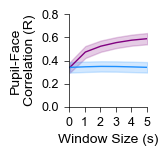

In [14]:
### Plot Fig1G
plt.figure(figsize = (1,1.2))
ax = sns.lineplot(data = median_df.groupby(["ID","Window","type"]).mean().reset_index(), x = "Window", y = "R",hue = "type",errorbar= "se",linewidth = 1,palette = ["Purple","dodgerblue"],legend=None)
format_ax(ax,(0,5),(0,0.8),1,0.2)
ax.set_ylabel("Pupil-Face\nCorrelation (R)")
ax.set_xlabel("Window Size (s)")




In [15]:
### Get all pupil events for Fig1H and Fig1I

id_date = {
"004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}
labels = ["1","2","3","4"]

df_list = []
for id,dates in id_date.items():
    for date in dates:
        events = get_pupil_events(id,date)
        events["animal_amp_bin"] = pd.qcut(events["amplitudes"], q=4,labels = labels)
        df_list.append(events)
        
event_df = pd.concat(df_list)



Text(0.5, 0, 'Dilation\n Duration (s)')

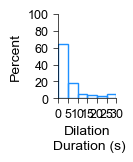

In [16]:
### Plot Fig1H (Left)
plt.figure(figsize = (0.75,1.1))
durations = event_df["durations"]
durations = np.clip(durations,a_max = 30,a_min = 0)
g = sns.histplot(data = durations,bins =[0,5,10,15,20,25,30],stat = "percent",fill =False,color = "dodgerblue",linewidth = 1)
g.set(xlabel ="Dilation Duration (s)")
g.set_xticks(np.arange(0,40,5))
g.set(xlim=(0,30))
g.set_yticks(np.arange(0,120,20))
g.set(ylim=(0,100))
labels = [item.get_text() for item in g.get_xticklabels()]
labels[-1] = '30+'
g.set_xticklabels(labels)
g.set_xlabel("Dilation\n Duration (s)")




Text(0.5, 0, 'Dilation\nAmplitude (z-scr)')

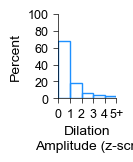

In [17]:
### Plot Fig1H (Right)
plt.figure(figsize = (0.75,1.1))
amplitudes = event_df["amplitudes"]
amplitudes = np.clip(amplitudes,a_max = 5,a_min = 0)
g = sns.histplot(data = amplitudes,bins =[0,1,2,3,4,5],stat = "percent",fill = False,color = "dodgerblue",linewidth = 1)
g.set(xlabel ="Dilation Amplitude")
g.set_xticks(np.arange(0,6,1))
g.set(xlim=(0,5))
g.set_yticks(np.arange(0,120,20))
g.set(ylim=(0,100))
labels = [item.get_text() for item in plt.gca().get_xticklabels()]
labels[-1] = '5+'
plt.gca().set_xticklabels(labels)
g.set_xlabel("Dilation\nAmplitude (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/4091577038.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = event_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(),x = "animal_amp_bin", y = "durations" ,errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/4091577038.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = event_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "durations",units = "ID",estimator = None,color = "black",a

Text(0, 0.5, 'Dilation\nDuration (s)')

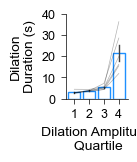

In [18]:
### Plot Fig1I
plt.figure(figsize = (0.8,1.1))
g = sns.barplot(data = event_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(),x = "animal_amp_bin", y = "durations" ,errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.lineplot(data = event_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "durations",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set(xlabel ="Dilation Amplitude", ylabel = "Dilation Duration")
g.set_yticks(np.arange(0,50,10))
g.set(ylim=(0,40))
g.set_xlabel("Dilation Amplitude\n Quartile")
g.set_ylabel("Dilation\nDuration (s)")

In [ ]:
### Get data for Fig1J (Left) and Fig1K (Left)

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        #onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))

  
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        onsets = [time[on] for on in events["onsets"]] ###get pupil onsets ix
        
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Dilation Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Facial Movement (z-scr)","ID" : id, "Date": date,"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        speed_matrix,speed_times = trial_align(onsets,time,speed,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(speed_matrix):
            baseline = np.mean(speed[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(speed_times):
                new_dict = {"Time from Dilation Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Speed (z-scr)","ID" : id, "Date": date,"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

align_df = pd.DataFrame.from_dict(df_list)

In [ ]:
### Get data for Fig1J (Right) and Fig1K (Right)

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

labels = ["1","2","3","4"]
df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = labels))

        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        for i,(on,off) in enumerate(zip(onsets,offsets)):
            baseline_face = np.mean(face[on-40:on-10]) 
            baseline_speed = np.mean(speed[on-40:on-10]) 


            during_face = np.mean(face[on:off])
            during_speed = np.mean(speed[on:off])

            new_dict = { "trial" : i,"ID" : id, "Date": date,"amp":amplitudes[i],"Dilation Amplitude\n Quartile":binned_amps[i],"∆ Facial\nMovement (z-scr)":during_face-baseline_face,"∆ Speed (z-scr)":during_speed-baseline_speed}
            df_list.append(new_dict)

bar_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/1376980734.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = align_df.groupby(["ID","Time from Dilation Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Facial Movement (z-scr)'").query("animal_amp_bin == [1,4]"), x = "Time from Dilation Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",legend=None,linewidth=1,palette= ["violet","purple"])


Text(0, 0.5, 'Facial\nMovement (z-scr)')

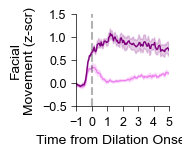

In [21]:
### Plot Fig1J (Left)
plt.figure(figsize = (1.2,1.2))
ax = sns.lineplot(data = align_df.groupby(["ID","Time from Dilation Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Facial Movement (z-scr)'").query("animal_amp_bin == [1,4]"), x = "Time from Dilation Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",legend=None,linewidth=1,palette= ["violet","purple"])

ax.axvline(0,linestyle = "--", color = "black",alpha = 0.3)
format_ax(ax,(-1,5),(-0.5,1.5),1,0.5)
ax.set_ylabel("Facial\nMovement (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/1640154837.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quartile", y = "∆ Facial\nMovement (z-scr)",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/1640154837.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quart

[(0.0, 1.0)]

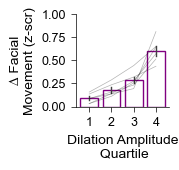

In [22]:
### Plot Fig1J (Right)
plt.figure(figsize = (1.2,1.2))
g = sns.barplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quartile", y = "∆ Facial\nMovement (z-scr)",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
sns.lineplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quartile", y = "∆ Facial\nMovement (z-scr)",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_yticks(np.arange(0,1.25,0.25))
g.set(ylim=(0,1))


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/1538290848.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = align_df.groupby(["ID","Time from Dilation Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Speed (z-scr)'").query("animal_amp_bin == [1,4]"), x = "Time from Dilation Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",legend=None,linewidth=1,palette= ["gold","darkorange"])


Text(0, 0.5, 'Speed (z-scr)')

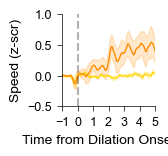

In [23]:
### Plot Fig1K (Left)
plt.figure(figsize = (1.2,1.2))
ax = sns.lineplot(data = align_df.groupby(["ID","Time from Dilation Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Speed (z-scr)'").query("animal_amp_bin == [1,4]"), x = "Time from Dilation Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",legend=None,linewidth=1,palette= ["gold","darkorange"])

ax.axvline(0,linestyle = "--", color = "black",alpha = 0.3)
format_ax(ax,(-1,5),(-0.5,1),1,0.5)
ax.set_ylabel("Speed (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/940534141.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quartile", y = "∆ Speed (z-scr)",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/940534141.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quartile", y =

[(-0.2, 0.6)]

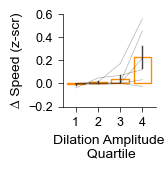

In [24]:
### Plot Fig1K (Right)
plt.figure(figsize = (1.2,1.2))
g = sns.barplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quartile", y = "∆ Speed (z-scr)",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
sns.lineplot(data = bar_df.groupby(["ID",'Dilation Amplitude\n Quartile']).mean().reset_index(), x = "Dilation Amplitude\n Quartile", y = "∆ Speed (z-scr)",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_yticks(np.arange(-0.2,0.8,0.2))
g.set(ylim=(-0.2,0.6))

In [ ]:
### Get data for Fig1L (Left), Fig1M (Left) and Fig1K (Left)

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
   "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])
     
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)

        #onsets = [time[on] for on in events["onsets"]] ###get pupil onsets ix
        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(trial[160:190])
            trial = trial-baseline
            if j in quiet_events:
                type = "quiet"
            elif j in move_events:
                type = "running"
            else:
                type = "neither"
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"Speed":type}
                df_list.append(new_dict)
                
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(trial[160:190])
            trial = trial-baseline
            if j in quiet_events:
                type = "quiet"
            elif j in move_events:
                type = "running"
            else:
                type = "neither"
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Face","ID" : id, "Date": date,"Speed":type}
                df_list.append(new_dict)

        speed_matrix,speed_times = trial_align(onsets,time,speed,fps = 20,pre = 10, post = 10)

        for j,trial in enumerate(speed_matrix):
            baseline = np.mean(trial[160:190])
            trial = trial-baseline
            if j in move_events:
                type = "running"
            elif j in quiet_events:
                type = "quiet"
            else:
                type = "neither"
            for i,Time in enumerate(speed_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Speed","ID" : id, "Date": date,"Speed":type}
                df_list.append(new_dict)

align_df = pd.DataFrame.from_dict(df_list)
align_df = align_df.query("Speed != 'neither'")


In [ ]:
### Get data for Fig1L (Right), Fig1M (Right) and Fig1K (Right)

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        offsets = [off/20 for off in events["offsets"]] ###get pupil offsets
        amplitudes = events["amplitudes"]


        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])

        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)

        for event in list(range(0,len(onsets))):
            on_ix = np.array(events["onsets"])[event]
            off_ix = np.array(events["offsets"])[event]

            baseline_speed = np.mean(speed[on_ix-40:on_ix-10])
            baseline_face = np.mean(face[on_ix-40:on_ix-10]) 



            face_movement = np.mean(face[on_ix:off_ix])
            wheel = np.mean(speed[on_ix:off_ix])

            if event in move_events:
                type = "Running"
            elif event in quiet_events:
                type = "Quiet"
            else:
                type = "neither"
            
            new_dict = {"ID": id, "date" : date,"type":type,"speed":wheel -baseline_speed,"face":face_movement-baseline_face,"amp":amplitudes[event]}
            df_list.append(new_dict)

bar_df = pd.DataFrame.from_dict(df_list).query("type != 'neither'")


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/3900960372.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'Pupil'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["cornflowerblue","darkblue"])


Text(0, 0.5, 'Pupil Size (z-scr)')

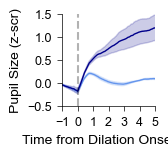

In [27]:
plt.figure(figsize = (1.2,1.2))

ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'Pupil'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["cornflowerblue","darkblue"])

ax.axvline(0,linestyle = "dashed", color = "black",alpha = 0.3)
format_ax(ax,(-1,5),(-0.5,1.5),1,0.5)
ax.set_xlabel("Time from Dilation Onset (s)")
ax.set_ylabel("Pupil Size (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2287828462.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "amp",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2287828462.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "amp",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


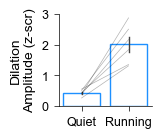

In [28]:
plt.figure(figsize = (1.2,1.2))
g = sns.barplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "amp",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.lineplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "amp",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_yticks(np.arange(0,4,1))
g.set(ylim=(0, 3))
g.set_ylabel("Dilation\nAmplitude (z-scr)")
g.xaxis.label.set_visible(False)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2513500508.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'Face'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["violet","purple"])


Text(0, 0.5, 'Facial\nMovement (z-scr)')

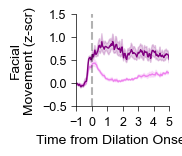

In [29]:
plt.figure(figsize = (1.2,1.2))

ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'Face'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["violet","purple"])

ax.axvline(0,linestyle = "dashed", color = "black",alpha = 0.3)
format_ax(ax,(-1,5),(-0.5,1.5),1,0.5)
ax.set_xlabel("Time from Dilation Onset (s)")
ax.set_ylabel("Facial\nMovement (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2744955154.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "face",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/2744955154.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "face",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


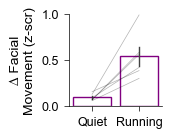

In [30]:
plt.figure(figsize = (1.2,1.2))
g = sns.barplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "face",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
sns.lineplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "face",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_yticks(np.arange(-1,1.5,0.5))
g.set(ylim=(0, 1))
g.set_ylabel("∆ Facial\nMovement (z-scr)")
g.xaxis.label.set_visible(False)




/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/313898719.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'Speed'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["gold","darkorange"])


Text(0, 0.5, 'Speed (z-scr)')

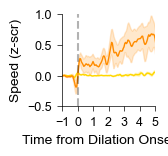

In [31]:
plt.figure(figsize = (1.2,1.2))
ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'Speed'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["gold","darkorange"])

ax.axvline(0,linestyle = "dashed", color = "black",alpha = 0.3)
format_ax(ax,(-1,5),(-0.5,1),1,0.5)
ax.set_xlabel("Time from Dilation Onset (s)")
ax.set_ylabel("Speed (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/3887653076.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "speed",errorbar = "se",fill = None,errwidth= 1,edgecolor  = "darkorange")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_9940/3887653076.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "speed",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


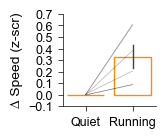

In [32]:
plt.figure(figsize = (1.2,1.2))
g = sns.barplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "speed",errorbar = "se",fill = None,errwidth= 1,edgecolor  = "darkorange")
sns.lineplot(data = bar_df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "speed",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_yticks(np.arange(-0.1,0.8,0.1))
g.set(ylim=(-0.1, 0.7))
g.set_ylabel("∆ Speed (z-scr)")
g.xaxis.label.set_visible(False)